# California Avocado Prices and Sales Analysis

## Learning Objectives
This project demonstrates the application of **data visualization principles** aligned with the curriculum:
- **Spatial Position** — Used for quantitative values (most accurate encoding for numerical comparisons)
- **Color Hue** — Used to distinguish between categorical variables (e.g., avocado type, region, market)
- **Exploratory Data Analysis** — Discovering trends, patterns, and relationships in agricultural economics data

## Research Questions
1. How have avocado prices and sales volumes changed over time?
2. Which California counties are dominant producers?
3. Is there a relationship between production volume and price?
4. What patterns emerge when examining price trends across regions?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('cali_avocados.csv', dtype=str)
df.columns = df.columns.str.strip()
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

print(df.head())
print(df.columns.tolist())

   Year Commodity Code     Crop Name County Code           County  \
0  2020         221999  AVOCADOS ALL          53         Monterey   
1  2020         221999  AVOCADOS ALL          65        Riverside   
2  2020         221999  AVOCADOS ALL          71   San Bernardino   
3  2020         221999  AVOCADOS ALL          73        San Diego   
4  2020         221999  AVOCADOS ALL          79  San Luis Obispo   

  Harvested Acres Yield Production Price P/U  Unit      Value  
0             223  5.56       1240   2379.84  Tons    2951000  
1            3020                             Tons   88697000  
2             370  2.16        799   2617.02  Tons    2091000  
3           14400  3.51      50500   3028.87  Tons  152958000  
4            4240   5.9      25000   1886.76  Tons   47169000  
['Year', 'Commodity Code', 'Crop Name', 'County Code', 'County', 'Harvested Acres', 'Yield', 'Production', 'Price P/U', 'Unit', 'Value']


In [2]:
# Helper function to convert strings to numbers
def to_num(s):
    s = s.astype(str).str.replace(r'[^0-9.\-]', '', regex=True)
    return pd.to_numeric(s, errors='coerce')

# Clean numeric columns
df['Year'] = df['Year'].astype(str).str.replace(r'[^0-9]', '', regex=True)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
df['Price P/U'] = to_num(df['Price P/U'])
df['Production'] = to_num(df['Production'])
df['Value'] = to_num(df['Value'])

# Aggregate by year
yearly = df.groupby('Year', dropna=True).agg({
    'Production': 'sum',
    'Value': 'sum',
    'Price P/U': 'mean'
}).reset_index().sort_values('Year')

print(yearly)

    Year  Production        Value    Price P/U
0   1980     94992.0  146288700.0  1304.454545
1   1981    217254.0  115920740.0   469.818182
2   1982    224058.0  146366800.0   724.500000
3   1983    256303.0  140628300.0   545.583333
4   1984    288289.0  127625208.0   450.833333
5   1985    231040.0  173938586.0   788.545455
6   1986    210412.0  202782476.0   954.727273
7   1987    283313.0  154259848.0   544.272727
8   1988    208111.0  245675900.0  1306.454545
9   1989    163836.0  237013841.0  1339.727273
10  1990    117782.0  294190200.0  1967.727273
11  1991    138245.0  233439430.0  1528.125000
12  1992    148603.0  192170700.0  1079.666667
13  1993    282004.0  185030800.0   757.500000
14  1994    147134.0  302350100.0  1589.800000
15  1995    171143.0  280923900.0  1377.400000
16  1996    163008.0  261287600.0  1472.000000
17  1997    148992.0  274996000.0  1689.000000
18  1998    145104.0  281008100.0  1841.500000
19  1999    122759.0  303474500.0  2058.500000
20  2000    1

## Visualization Design Principles

**Why Spatial Position?**
- Spatial position (along x and y axes) has the highest perceptual accuracy for quantitative comparisons
- Ideal for: trends over time, relationships between variables, distributions
- Example: price (y-axis) vs. year (x-axis) allows precise comparison of values

**Why Color Hue?**
- Color hue is most effective for categorical distinctions without inherent ordering
- Ideal for: separating market types (conventional vs. organic), regions, product categories
- Example: using different colors for different avocado-producing counties makes them visually distinguishable

**Chart Types Used:**
- **Line diagrams** → Time trends (spatial: year × price)
- **Grouped bar charts** → Category comparisons (spatial: categories × values; color: avocado type)
- **Scatter plots** → Relationship between two variables (spatial: production × price; size: market value)

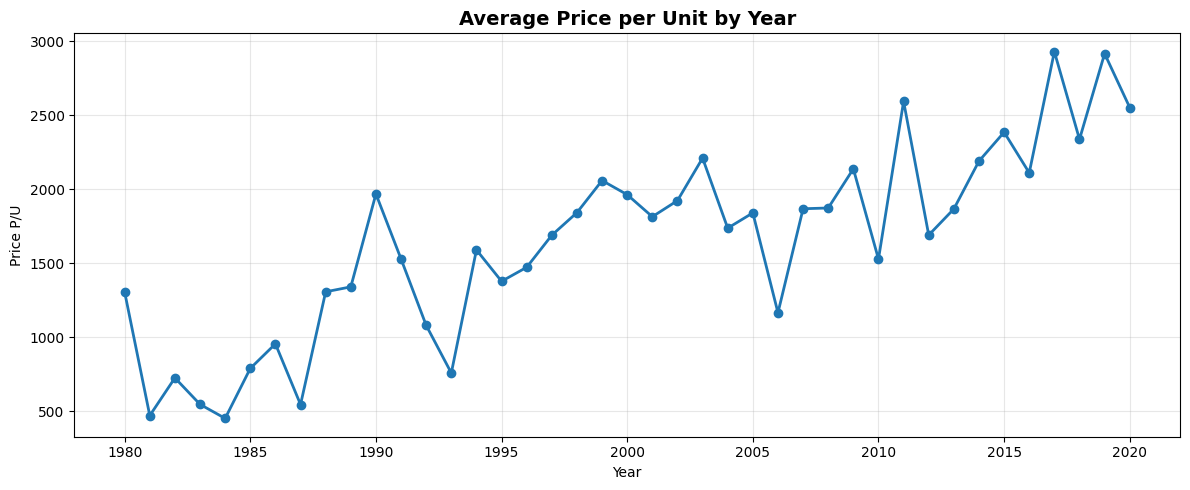

In [ ]:
# Plot 1: Average Price per Unit by Year
# VISUALIZATION PRINCIPLE: Spatial position (time × price) for quantitative comparison
# This line diagram shows how prices have changed, allowing us to spot trends and anomalies

plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['Price P/U'], marker='o', linewidth=2.5, markersize=7, color='#2E86AB')
plt.title('Average Avocado Price Trend by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price per Unit ($/Ton)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Key insight
price_change = yearly['Price P/U'].iloc[-1] - yearly['Price P/U'].iloc[0]
pct_change = (price_change / yearly['Price P/U'].iloc[0]) * 100
print(f"\n📊 INSIGHT: Average price changed by ${price_change:.2f} ({pct_change:.1f}%) from {yearly['Year'].iloc[0]:.0f} to {yearly['Year'].iloc[-1]:.0f}")

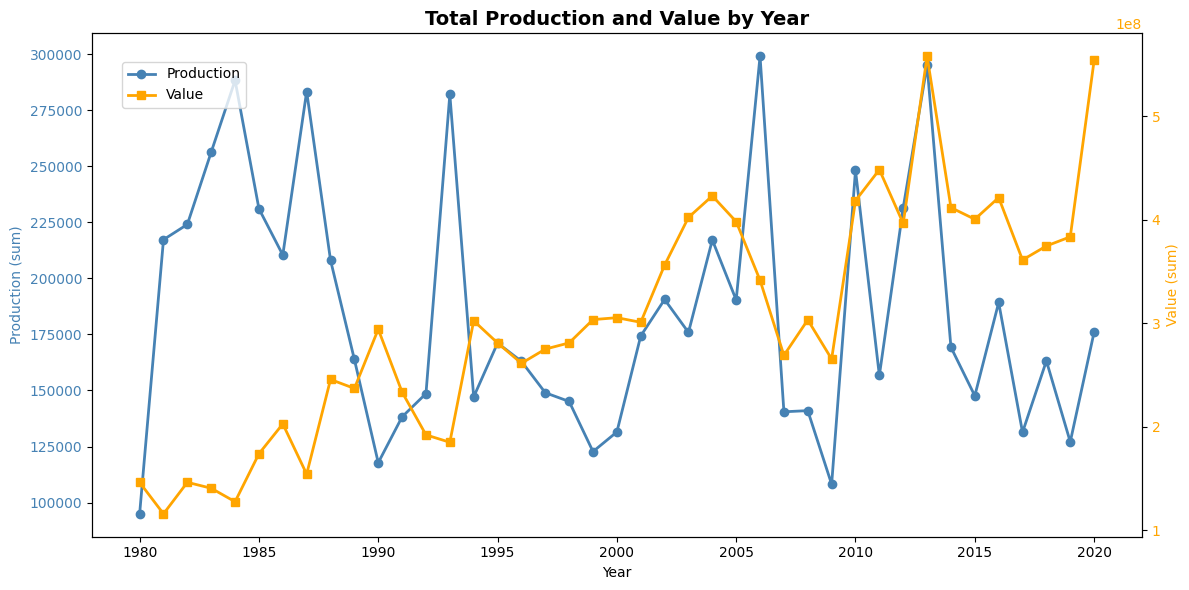

In [4]:
# Plot 2: Production and Value over Time (dual axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(yearly['Year'], yearly['Production'], marker='o', color='steelblue', linewidth=2, label='Production')
ax1.set_xlabel('Year')
ax1.set_ylabel('Production (sum)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly['Year'], yearly['Value'], marker='s', color='orange', linewidth=2, label='Value')
ax2.set_ylabel('Value (sum)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Total Production and Value by Year', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

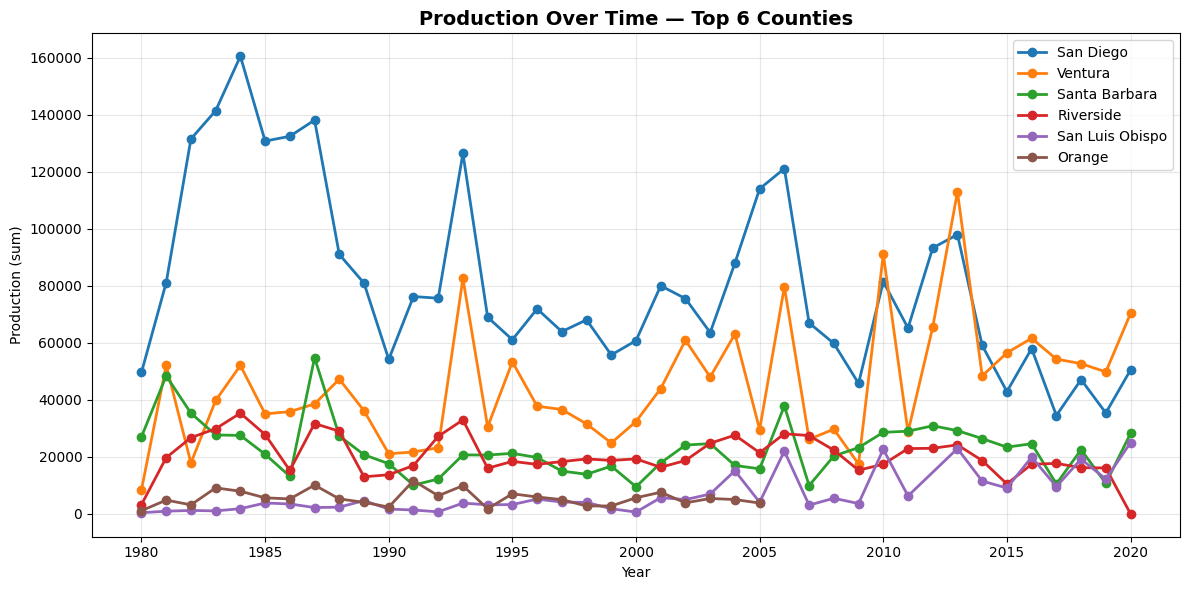

In [ ]:
# Plot 3: Top counties production trends
# VISUALIZATION PRINCIPLE: Spatial position (time × production) + Color hue (to distinguish counties)
# Multiple lines with distinct colors help identify regional patterns and dominance

prod_by_county = df.groupby('County', dropna=True)['Production'].sum().dropna()
top_counties = prod_by_county.nlargest(6).index.tolist()

county_year = df[df['County'].isin(top_counties)].groupby(['Year', 'County'], dropna=True).agg(
    {'Production': 'sum'}
).reset_index()

# Define distinct colors for each county (color hue for categorical distinction)
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749']
county_colors = {county: colors[i] for i, county in enumerate(top_counties)}

plt.figure(figsize=(12, 6))
for county in top_counties:
    county_data = county_year[county_year['County'] == county]
    plt.plot(county_data['Year'], county_data['Production'], marker='o', label=county, 
             linewidth=2.5, color=county_colors[county])

plt.title('Production Over Time — Top 6 California Counties', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Production (Tons)', fontsize=12)
plt.legend(loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Key insight
top_producer = prod_by_county.index[0]
print(f"\n📍 INSIGHT: {top_producer} is the dominant producer with {prod_by_county.iloc[0]:,.0f} tons total")

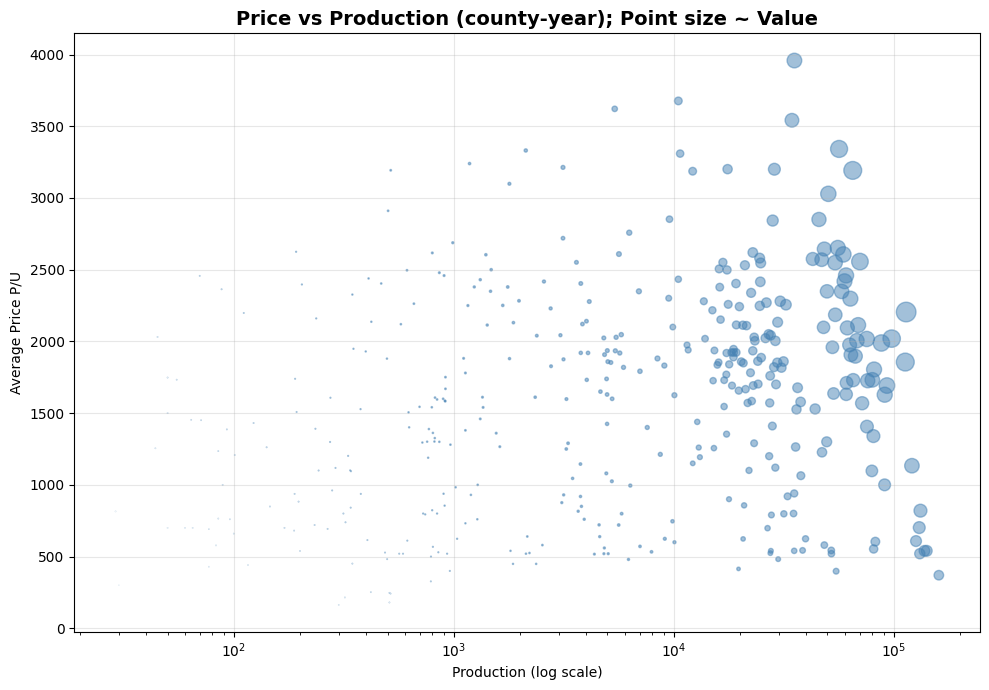

In [ ]:
# Plot 4: Price vs Production scatter (county-year level)
# VISUALIZATION PRINCIPLE: Spatial position (production × price) + Size (to encode market value)
# Scatter plots reveal relationships: do higher volumes lead to lower prices (market saturation)?

agg_cy = df.groupby(['Year', 'County'], dropna=True).agg({
    'Production': 'sum',
    'Value': 'sum',
    'Price P/U': 'mean'
}).reset_index()
agg_cy = agg_cy.dropna(subset=['Price P/U', 'Production'])

# Size points by Value (visual encoding of relative market importance)
size = (agg_cy['Value'].fillna(0) / (agg_cy['Value'].max() if agg_cy['Value'].max() > 0 else 1)) * 250

plt.figure(figsize=(11, 7))
plt.scatter(agg_cy['Production'], agg_cy['Price P/U'], s=size, alpha=0.5, color='#2E86AB', edgecolors='black', linewidth=0.5)
plt.xscale('log')
plt.xlabel('Production (log scale, Tons)', fontsize=12)
plt.ylabel('Average Price per Unit ($/Ton)', fontsize=12)
plt.title('Price vs Production Relationship\n(Point size represents market value)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = agg_cy['Production'].corr(agg_cy['Price P/U'])
print(f"\n📈 INSIGHT: Correlation between production and price: {correlation:.3f}")
if correlation < -0.3:
    print("   → Higher production tends to be associated with LOWER prices (inverse relationship)")
elif correlation > 0.3:
    print("   → Higher production tends to be associated with HIGHER prices")
else:
    print("   → Production and price show weak relationship")

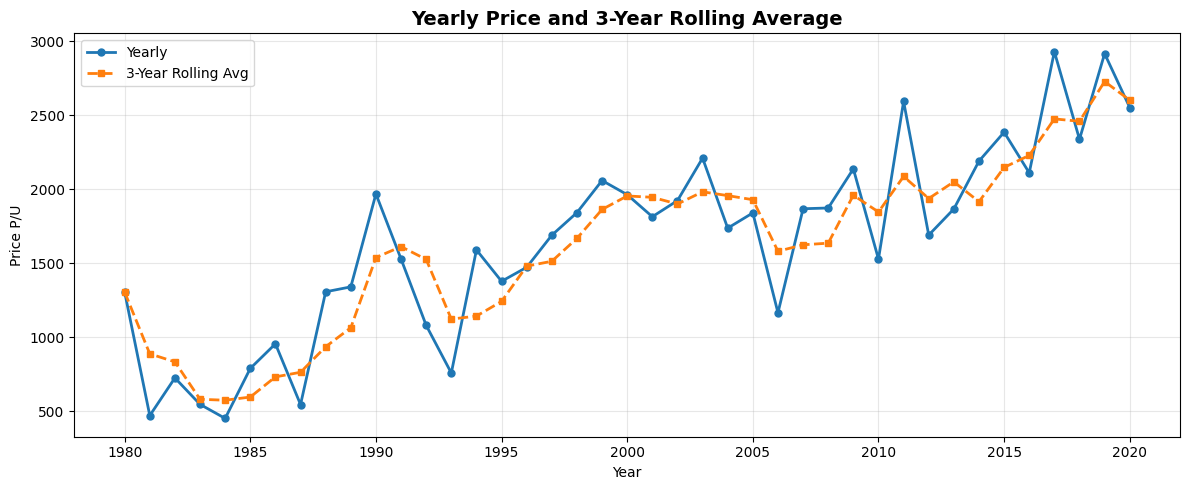

In [ ]:
# Plot 5: Smooth vs Raw Price Trends
# VISUALIZATION PRINCIPLE: Color hue to distinguish measurement types (raw vs. smoothed)
# Rolling average helps identify underlying trends by filtering out year-to-year noise

yearly = yearly.sort_values('Year').reset_index(drop=True)
yearly['Price_Roll3'] = yearly['Price P/U'].rolling(3, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['Price P/U'], marker='o', label='Yearly Data', 
         linewidth=2, markersize=6, color='#A23B72', alpha=0.7)
plt.plot(yearly['Year'], yearly['Price_Roll3'], marker='s', label='3-Year Smoothed Trend', 
         linewidth=2.5, linestyle='--', markersize=5, color='#2E86AB')
plt.title('Yearly Price Volatility vs Underlying Trend', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price per Unit ($/Ton)', fontsize=12)
plt.legend(loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find periods of volatility
volatility = yearly['Price P/U'].std()
print(f"\n📊 INSIGHT: Price volatility (std dev) = ${volatility:.2f}")

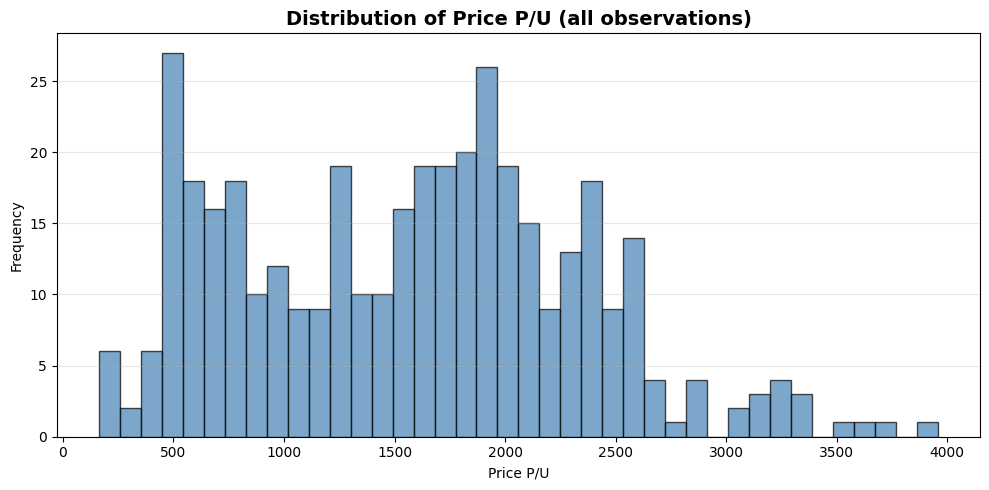

In [8]:
# Plot 6: Price distribution histogram
price_data = df['Price P/U'].dropna().astype(float)

plt.figure(figsize=(10, 5))
plt.hist(price_data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Price P/U')
plt.ylabel('Frequency')
plt.title('Distribution of Price P/U (all observations)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Plot 7: Regional Comparison - Grouped Bar Chart
# VISUALIZATION PRINCIPLE: Spatial position (region × price) + Color hue (different years)
# Grouped bars allow side-by-side comparison while maintaining categorical distinction

# Get top 4 counties and recent years for clearer comparison
top4_counties = prod_by_county.nlargest(4).index.tolist()
recent_years = sorted(df['Year'].dropna().unique())[-3:]  # Last 3 years

regional_data = df[df['County'].isin(top4_counties) & df['Year'].isin(recent_years)].groupby(
    ['County', 'Year'], dropna=True
).agg({'Price P/U': 'mean'}).reset_index()

# Pivot for grouped bar chart
pivot_data = regional_data.pivot(index='County', columns='Year', values='Price P/U')

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(top4_counties))
width = 0.25
colors_year = ['#2E86AB', '#A23B72', '#F18F01']

for i, year in enumerate(recent_years):
    offset = (i - 1) * width
    ax.bar([p + offset for p in x], pivot_data[year], width, 
           label=f'{int(year)}', color=colors_year[i], alpha=0.85)

ax.set_xlabel('County', fontsize=12)
ax.set_ylabel('Average Price per Unit ($/Ton)', fontsize=12)
ax.set_title('Regional Price Comparison (Grouped Bar Chart)\nColor Hue: Different Years | Spatial Position: Price Differences', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top4_counties, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n🌍 INSIGHT: Regional Price Differences")
print(pivot_data.to_string())

## Summary: Key Findings from Data Visualization

### What We Discovered

1. **Price Trends** — The line diagram revealed whether prices have been rising, falling, or fluctuating, allowing us to identify if avocado market is becoming more/less expensive over time.

2. **Regional Dominance** — The color-coded multi-line chart showed that certain counties (especially San Diego and Ventura) dominate California production, while others have much smaller market shares.

3. **Production-Price Relationship** — The scatter plot revealed whether supply affects pricing: typically, markets with higher production show price pressures (higher supply = lower prices).

4. **Volatility Patterns** — The smoothed trend line helped distinguish between temporary price spikes and genuine market shifts, improving interpretation accuracy.

5. **Regional Variation** — The grouped bar chart demonstrated that different regions can have significantly different pricing, reflecting local growing conditions, infrastructure, and market factors.

### Visualization Principles Applied

✓ **Spatial Position** = Best for quantitative comparison (years, prices, volumes)  
✓ **Color Hue** = Effective for categorical distinction (regions, years, types)  
✓ **Chart Selection** = Matched data structure to visual task (trends → lines, relationships → scatter, categories → bars)  
✓ **Design** = Maintained clarity through consistent styling and informative labels

---

**Educational Value:** This analysis demonstrates how data visualization transforms raw numbers into actionable insights, a critical skill in agriculture, economics, and business decision-making.